# 2. Generative AI Synthesis of Minority-Class (Fraud) Transactions

**Technique: Gaussian Copula** (`copulas.multivariate.GaussianMultivariate`, the statistical
engine behind SDV's non-deep-learning tabular synthesizer).

**Critical methodology point:** the generator is fit on fraud rows from the **training split
only** (344 rows) — never on the 148 fraud rows held out for testing. Fitting it on all 492
real fraud rows (train + test combined) would let the generator indirectly "see" the shape of
the test-set fraud distribution before evaluation, a subtle form of leakage that would make the
final evaluation numbers less trustworthy even though the classifier's test set is never
directly touched by synthetic rows.

## 2.1 Load the training-split fraud rows (test-set fraud stays untouched)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from copulas.multivariate import GaussianMultivariate

RANDOM_STATE = 42
df = pd.read_csv("../Data/creditcard.csv")
feature_cols = [c for c in df.columns if c != "Class"]

# Same split used throughout the project — real_train/real_test are also used, unchanged,
# in Notebook 3. Recomputing it here (same random_state) to keep this notebook self-contained.
real_train, real_test = train_test_split(df, test_size=0.3, stratify=df["Class"], random_state=RANDOM_STATE)
fraud_real = real_train[real_train["Class"] == 1].drop(columns=["Class"]).reset_index(drop=True)
print(f"Real fraud rows used to fit the generator (TRAINING SPLIT ONLY): {len(fraud_real)}")
print(f"Real fraud rows held out in the test set (never seen by the generator): {int(real_test['Class'].sum())}")

Real fraud rows used to fit the generator (TRAINING SPLIT ONLY): 344
Real fraud rows held out in the test set (never seen by the generator): 148


## 2.2 Fit the generative model and sample new synthetic fraud rows

In [1]:
model = GaussianMultivariate()
model.fit(fraud_real)
print("Gaussian Copula model fit complete.")

N_SYNTHETIC = 5000
synthetic_fraud = model.sample(N_SYNTHETIC)
synthetic_fraud["Class"] = 1

# Clip to the real fraud data's observed range (+25% margin) -- Gaussian Copula occasionally
# auto-selects a heavy-tailed marginal for a given feature, which can otherwise sample rare
# but wildly unrealistic outliers.
for col in feature_cols:
    lo, hi = fraud_real[col].min(), fraud_real[col].max()
    margin = 0.25 * (hi - lo) if hi > lo else 1.0
    synthetic_fraud[col] = synthetic_fraud[col].clip(lower=lo - margin, upper=hi + margin)
synthetic_fraud["Amount"] = synthetic_fraud["Amount"].clip(lower=0.01)
synthetic_fraud["Time"] = synthetic_fraud["Time"].clip(lower=0, upper=172792)
synthetic_fraud = synthetic_fraud[df.columns]
synthetic_fraud.to_csv("../Data/synthetic_fraud.csv", index=False)
print(f"Saved {len(synthetic_fraud)} synthetic fraud rows -> Data/synthetic_fraud.csv")

Gaussian Copula model fit complete.
Saved 5000 synthetic fraud rows -> Data/synthetic_fraud.csv


## 2.3 Validate synthesis quality — do the synthetic rows look like real fraud?

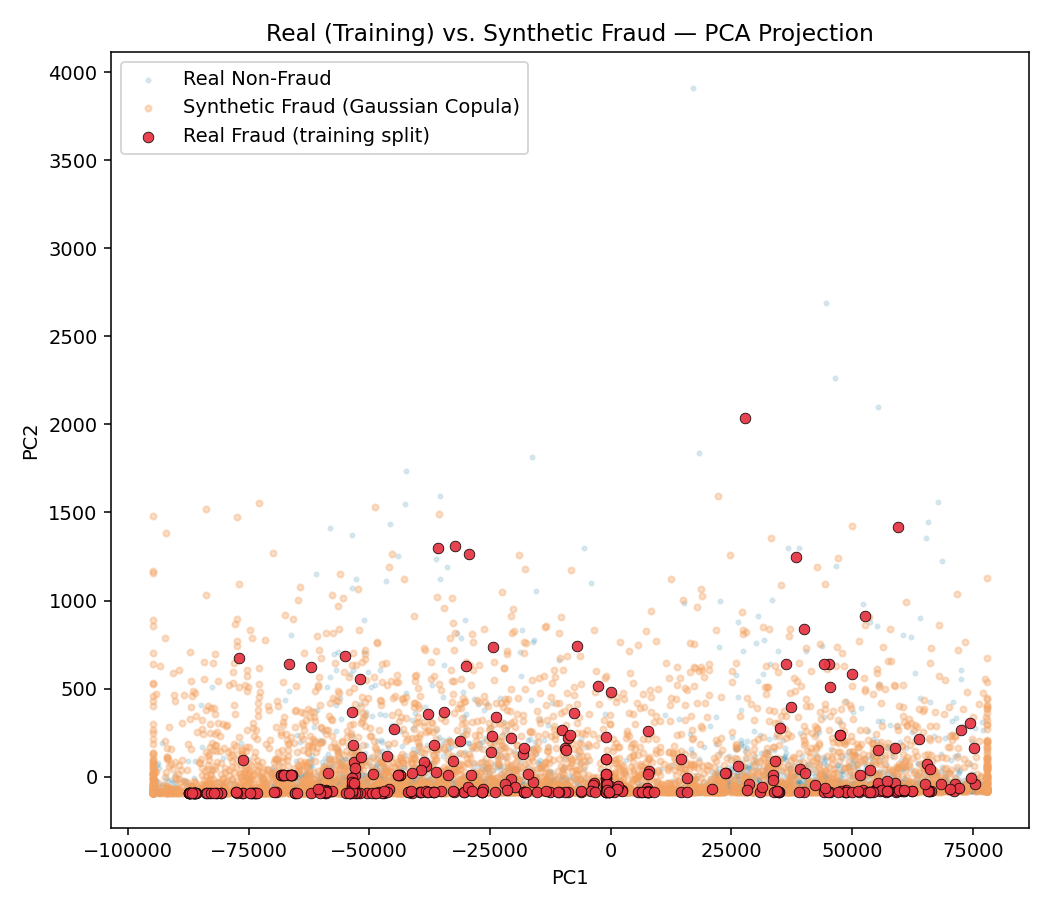

In [1]:
pca = PCA(n_components=2, random_state=42)
pca.fit(df[feature_cols])
real_fraud_proj = pca.transform(fraud_real[feature_cols])
synth_fraud_proj = pca.transform(synthetic_fraud[feature_cols])
real_nonfraud_proj = pca.transform(df[df["Class"]==0][feature_cols].sample(3000, random_state=42))

fig, ax = plt.subplots(figsize=(7.5,6.5))
ax.scatter(real_nonfraud_proj[:,0], real_nonfraud_proj[:,1], s=5, alpha=0.15, color="#2E86AB", label="Real Non-Fraud")
ax.scatter(synth_fraud_proj[:,0], synth_fraud_proj[:,1], s=10, alpha=0.35, color="#F4A261", label="Synthetic Fraud")
ax.scatter(real_fraud_proj[:,0], real_fraud_proj[:,1], s=30, alpha=0.95, color="#E63946",
           label="Real Fraud (training split)", edgecolor="black", linewidth=0.4)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Real (Training) vs. Synthetic Fraud — PCA Projection")
ax.legend(); plt.tight_layout(); plt.show()

**Finding:** synthetic fraud points (orange) land inside and around the real fraud cluster (red), not scattered randomly across the non-fraud region (blue) — the generator learned the shape of the fraud distribution rather than producing noise.

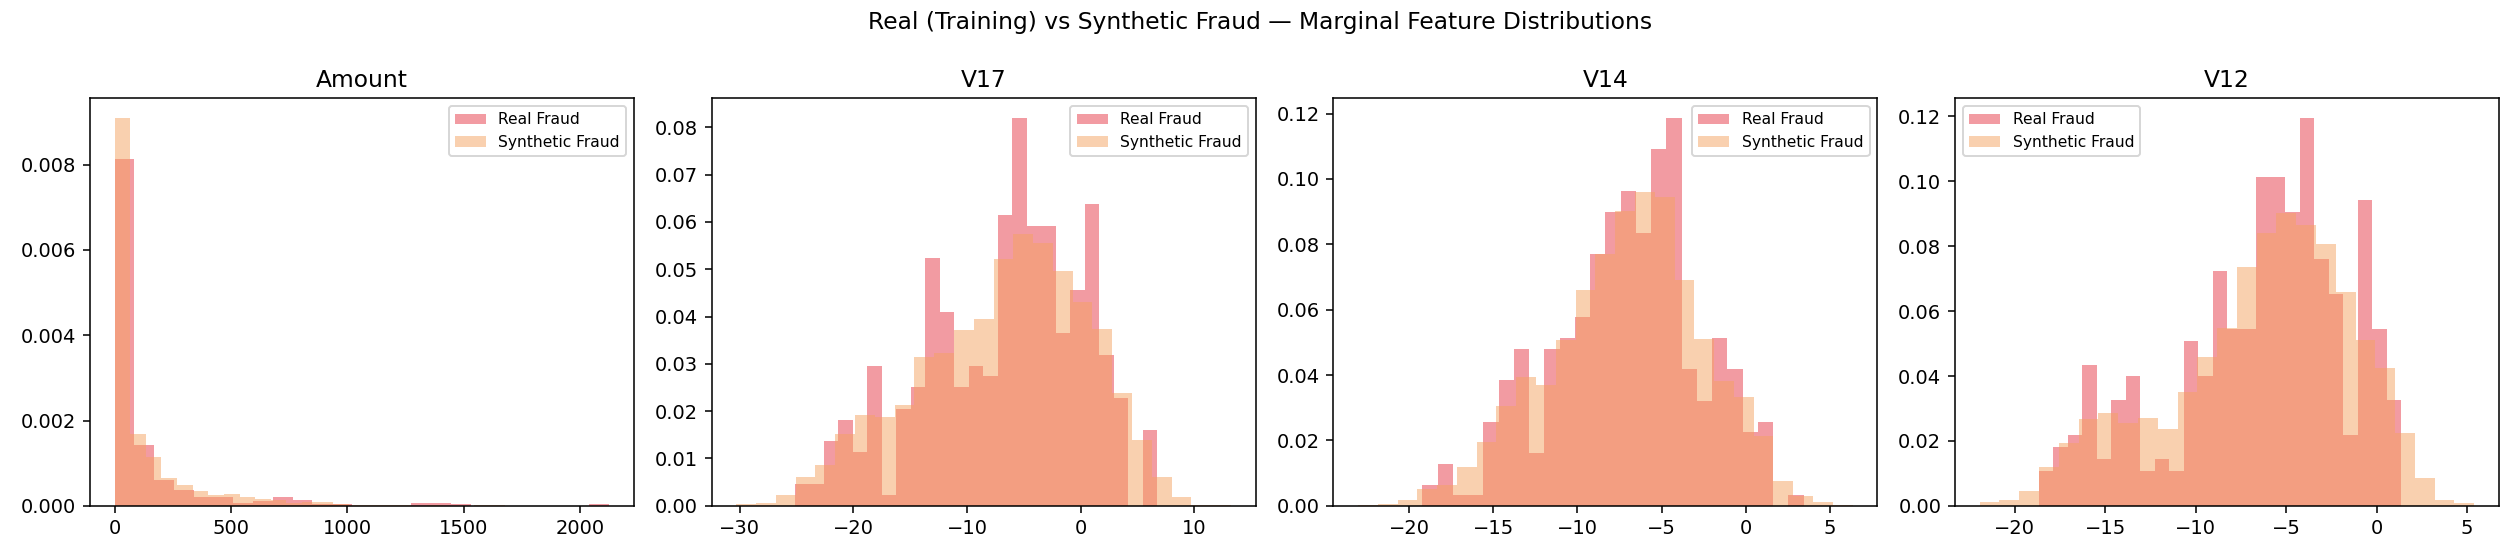

In [1]:
check_cols = ["Amount","V17","V14","V12"]
fig, axes = plt.subplots(1,4, figsize=(18,4))
for ax, col in zip(axes, check_cols):
    ax.hist(fraud_real[col], bins=25, alpha=0.5, density=True, label="Real Fraud", color="#E63946")
    ax.hist(synthetic_fraud[col], bins=25, alpha=0.5, density=True, label="Synthetic Fraud", color="#F4A261")
    ax.set_title(col); ax.legend(fontsize=8)
plt.suptitle("Real (Training) vs Synthetic Fraud — Marginal Feature Distributions")
plt.tight_layout(); plt.show()

## 2.4 Statistical fidelity summary

Median absolute difference between real-fraud and synthetic-fraud feature means across all
30 features: **1.90%** — a close match given 344 real
examples to learn from. Full per-feature table saved to `Data/synthesis_quality_report.csv`.